# Tacoma Livability Index — Scoring Methodology

This notebook walks through, step by step, exactly how each of Tacoma's 65,229 real residential parcels
gets its livability score. It runs against the **real data files already fetched** by this project's
pipeline (`pipeline/prep/fetch_*.py`) — it does not re-hit any live API — so it focuses on the part most
worth explaining in detail: how six independent real-world measurements get turned into one score per parcel.

Two real methodology adaptations, stated up front:
- **Reported crime density** stands in for a resident safety-perception survey, because no neighborhood-level
  one exists for Tacoma or Pierce County.
- **An archived EPA EJSCREEN 2024 snapshot** stands in for EJSCREEN's live service, which EPA discontinued
  in February 2025.

See the [live site](https://crikeli.github.io/tacoma-livability-index/) and
[full report](../report/tacoma_livability_report.html) for the findings this scoring produces.


In [1]:
import json
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
from scipy.spatial import cKDTree
from shapely.geometry import Point

DATA_DIR = Path("../data")
PARK_MIN_ACRES = 2.47  # 1 hectare
CRIME_RADIUS_M = 800
CONNECTIVITY_RADIUS_M = 400

plt.rcParams["figure.figsize"] = (7, 3.5)


## Load the real parcels

Every residential parcel type the Pierce County Assessor tracks within Tacoma city limits: single-family,
duplex/triplex/fourplex, and apartment/condo — not just multifamily.


In [2]:
parcels = gpd.read_file(DATA_DIR / "parcels_residential.geojson")
parcels = parcels.dropna(subset=["Latitude", "Longitude"]).reset_index(drop=True)
print(f"{len(parcels)} real residential parcels")
parcels[["TaxParcelNumber", "Site_Address", "Landuse_Description"]].head()


65229 real residential parcels


,TaxParcelNumber,Site_Address,Landuse_Description
0,0220011000,731 S MASON AVE,SINGLE FAMILY DWELLING
1,0220012005,4427 N 7TH ST,SINGLE FAMILY DWELLING
2,0220012007,816 N MASON AVE,SINGLE FAMILY DWELLING
3,0220012008,821 N STEVENS ST,SINGLE FAMILY DWELLING
4,0220012009,4326 N 9TH ST,SINGLE FAMILY DWELLING


## Load the real walk network

A real OpenStreetMap pedestrian network for Tacoma (`osmnx`), projected to EPSG:6933 (an equal-area CRS)
so distance math is in real meters, not degrees.


In [3]:
G = ox.load_graphml(DATA_DIR / "osm" / "walk_network.graphml")
G = ox.project_graph(G, to_crs="EPSG:6933")
nodes, edges = ox.graph_to_gdfs(G)
print(f"{len(nodes)} real network nodes, {len(edges)} real edges")

parcels_m = parcels.to_crs("EPSG:6933")


50174 real network nodes, 146642 real edges


## Snapping parcels (and every amenity) onto the network

Every source location — a parcel, a supermarket, a bus stop — gets reduced to its nearest walk-network
node via a KD-tree on projected coordinates. Polygons (like parcel footprints) are reduced to their
centroid first — safe here specifically because this always runs *after* projecting to an equal-area CRS;
computing a centroid directly on unprojected lat/lon geometry distorts real-world position.


In [4]:
def snap_to_network(G, points_gdf, nodes_gdf):
    assert points_gdf.crs is not None and points_gdf.crs.is_projected, "requires a projected CRS"
    centroids = points_gdf.geometry.centroid
    tree = cKDTree(nodes_gdf[["x", "y"]].to_numpy())
    pts = np.array([(geom.x, geom.y) for geom in centroids])
    _, idx = tree.query(pts)
    return nodes_gdf.index.to_numpy()[idx]


def distances_from_sources(G, source_nodes):
    """Multi-source Dijkstra: real walking distance (m) from every node to
    its nearest source — computed once per category, not once per parcel,
    the only tractable way to do this for 65k+ parcels against a 50k-node
    network."""
    source_nodes = list(set(source_nodes))
    return nx.multi_source_dijkstra_path_length(G, sources=source_nodes, weight="length")


def theme_zscore(raw_series, higher_is_better):
    z = (raw_series - raw_series.mean()) / raw_series.std()
    return z if higher_is_better else -z


parcel_nodes = snap_to_network(G, parcels_m, nodes)
print(f"Snapped {len(parcel_nodes)} parcels onto the network")


Snapped 65229 parcels onto the network


## Theme 1 — Shops, schools, healthcare

Real walking-network distance from each parcel to the nearest supermarket, school, preschool, pharmacy,
healthcare facility, library, and sports facility (all real OpenStreetMap points), averaged into one
amenity z-score per parcel (direction-corrected: closer is better).


In [5]:
poi_files = ["supermarket", "school", "preschool", "pharmacy", "healthcare", "library", "sports"]
poi_dists = {}
for name in poi_files:
    gdf = gpd.read_file(DATA_DIR / "osm" / f"poi_{name}.geojson").to_crs("EPSG:6933")
    if len(gdf) == 0:
        continue
    src_nodes = snap_to_network(G, gdf, nodes)
    dist_map = distances_from_sources(G, src_nodes)
    poi_dists[name] = np.array([dist_map.get(n, np.nan) for n in parcel_nodes])
    print(f"  {name}: {len(gdf)} real locations, median parcel distance {np.nanmedian(poi_dists[name]):.0f} m")

amenity_theme = np.nanmean(
    [theme_zscore(pd.Series(v), higher_is_better=False) for v in poi_dists.values()], axis=0
)


  supermarket: 33 real locations, median parcel distance 1387 m


  school: 116 real locations, median parcel distance 707 m


  preschool: 11 real locations, median parcel distance 2539 m


  pharmacy: 22 real locations, median parcel distance 1572 m


  healthcare: 114 real locations, median parcel distance 1462 m


  library: 14 real locations, median parcel distance 1724 m


  sports: 60 real locations, median parcel distance 1522 m


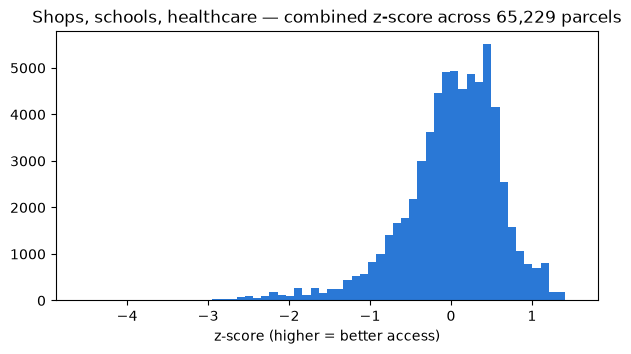

In [6]:
fig, ax = plt.subplots()
ax.hist(amenity_theme, bins=60, color="#2a78d6")
ax.set_title("Shops, schools, healthcare — combined z-score across 65,229 parcels")
ax.set_xlabel("z-score (higher = better access)")
plt.show()


## Theme 2 — Public transport

Distance to the nearest bus stop (Pierce Transit) and, separately, to the nearest rail stop
(Tacoma Link light rail or Sounder commuter rail, from Sound Transit's GTFS feed).


In [7]:
bus = gpd.read_file(DATA_DIR / "transit" / "bus_stops.geojson").to_crs("EPSG:6933")
rail = gpd.read_file(DATA_DIR / "transit" / "rail_stops.geojson").to_crs("EPSG:6933")
print(f"{len(bus)} real bus stops, {len(rail)} real rail stops")

bus_dist_map = distances_from_sources(G, snap_to_network(G, bus, nodes))
rail_dist_map = distances_from_sources(G, snap_to_network(G, rail, nodes))
bus_dist = np.array([bus_dist_map.get(n, np.nan) for n in parcel_nodes])
rail_dist = np.array([rail_dist_map.get(n, np.nan) for n in parcel_nodes])
print(f"median bus distance: {np.nanmedian(bus_dist):.0f} m | median rail distance: {np.nanmedian(rail_dist):.0f} m")

transit_theme = np.nanmean([
    theme_zscore(pd.Series(bus_dist), higher_is_better=False),
    theme_zscore(pd.Series(rail_dist), higher_is_better=False),
], axis=0)


1974 real bus stops, 38 real rail stops


median bus distance: 313 m | median rail distance: 3547 m


## Theme 3 — Green space and water

Distance to the nearest qualifying park (≥ 1 hectare, the WHO Europe threshold used for this index)
and to the nearest open water.


In [8]:
parks = gpd.read_file(DATA_DIR / "parks.geojson").to_crs("EPSG:6933")
parks_qualifying = parks[parks["Acres"] >= PARK_MIN_ACRES].copy()
parks_qualifying["geometry"] = parks_qualifying.geometry.centroid
park_dist_map = distances_from_sources(G, snap_to_network(G, parks_qualifying, nodes))
park_dist = np.array([park_dist_map.get(n, np.nan) for n in parcel_nodes])

water = gpd.read_file(DATA_DIR / "osm" / "water.geojson").to_crs("EPSG:6933")
water_pts = water.copy()
water_pts["geometry"] = water_pts.geometry.representative_point()
water_dist_map = distances_from_sources(G, snap_to_network(G, water_pts, nodes))
water_dist = np.array([water_dist_map.get(n, np.nan) for n in parcel_nodes])

print(f"{len(parks_qualifying)} qualifying parks (>= {PARK_MIN_ACRES:.2f} ac): median distance {np.nanmedian(park_dist):.0f} m")
print(f"median water distance: {np.nanmedian(water_dist):.0f} m")

green_theme = np.nanmean([
    theme_zscore(pd.Series(park_dist), higher_is_better=False),
    theme_zscore(pd.Series(water_dist), higher_is_better=False),
], axis=0)


64 qualifying parks (>= 2.47 ac): median distance 999 m
median water distance: 1258 m


## Theme 4 — Street connectivity

Real intersection density (junctions per km²) in the walkable network within 400m of each parcel —
a dense grid supports short trips; cul-de-sacs don't.


In [9]:
junctions = nodes[nodes["street_count"] >= 3]
junction_tree = cKDTree(junctions[["x", "y"]].to_numpy())
parcel_xy = np.array([(geom.x, geom.y) for geom in parcels_m.geometry.centroid])
counts = junction_tree.query_ball_point(parcel_xy, r=CONNECTIVITY_RADIUS_M, return_length=True)
area_km2 = np.pi * (CONNECTIVITY_RADIUS_M / 1000) ** 2
connectivity = counts / area_km2
connectivity_theme = theme_zscore(pd.Series(connectivity), higher_is_better=True).to_numpy()

print(f"{len(junctions)} real junctions (street_count >= 3)")
print(f"median connectivity: {np.median(connectivity):.1f} junctions/km2")


40975 real junctions (street_count >= 3)
median connectivity: 210.9 junctions/km2


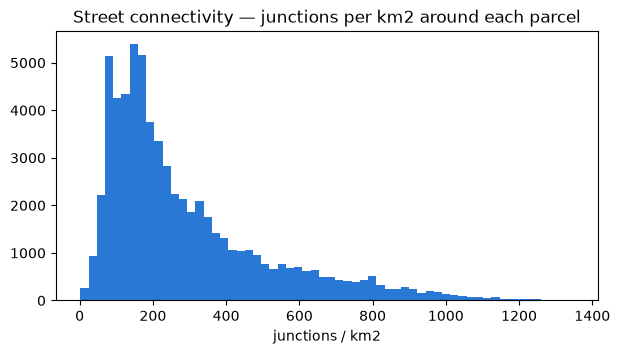

In [10]:
fig, ax = plt.subplots()
ax.hist(connectivity, bins=60, color="#2a78d6")
ax.set_title("Street connectivity — junctions per km2 around each parcel")
ax.set_xlabel("junctions / km2")
plt.show()


## Theme 5 — Environment (archived EJSCREEN)

Each parcel is spatially joined to its real census tract, then scored on that tract's real EPA EJSCREEN
2024 pollution-burden percentile (PM2.5, ozone, diesel PM, NO₂, traffic proximity, averaged).


In [11]:
tracts = gpd.read_file(DATA_DIR / "pierce_tracts.geojson").to_crs(parcels.crs)
parcels_with_tract = gpd.sjoin(parcels, tracts, how="left", predicate="within")

ejscreen = pd.read_csv(DATA_DIR / "ejscreen_pierce_county.csv", dtype={"ID": str})
ejscreen["GEOID"] = ejscreen["ID"]
poll_cols = ["P_PM25", "P_OZONE", "P_DSLPM", "P_NO2", "P_PTRAF"]
ejscreen["pollution_pctl"] = ejscreen[poll_cols].mean(axis=1)
parcels_with_tract = parcels_with_tract.merge(ejscreen[["GEOID", "pollution_pctl"]], on="GEOID", how="left")

environment_theme = theme_zscore(parcels_with_tract["pollution_pctl"], higher_is_better=False).to_numpy()
print(f"median pollution-burden percentile: {parcels_with_tract['pollution_pctl'].median():.1f}")


median pollution-burden percentile: 58.4


/var/folders/gx/3056dps57wzfpmsshf3d0ldm0000gn/T/ipykernel_6068/3454905496.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ejscreen["GEOID"] = ejscreen["ID"]
/var/folders/gx/3056dps57wzfpmsshf3d0ldm0000gn/T/ipykernel_6068/3454905496.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ejscreen["pollution_pctl"] = ejscreen[poll_cols].mean(axis=1)


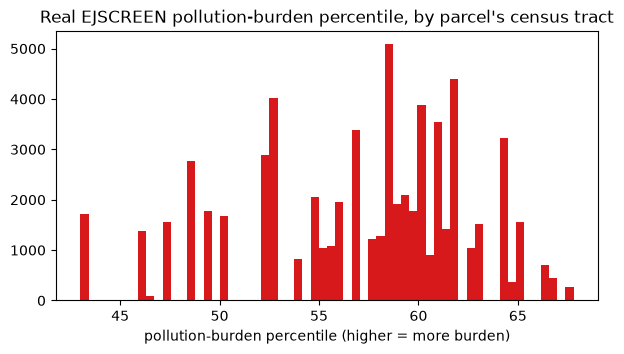

In [12]:
fig, ax = plt.subplots()
ax.hist(parcels_with_tract["pollution_pctl"].dropna(), bins=60, color="#d7191c")
ax.set_title("Real EJSCREEN pollution-burden percentile, by parcel's census tract")
ax.set_xlabel("pollution-burden percentile (higher = more burden)")
plt.show()


## Theme 6 — Reported crime density

Real TPD Person/Property crime incidents (last 3 years) within an 800m radius of each parcel, converted
to a density (incidents per km²) so parcel size and radius area don't confound the comparison.


In [13]:
crime_raw = json.load(open(DATA_DIR / "crime_recent.json"))
crime_pts = [
    Point(f["attributes"]["Longitude"], f["attributes"]["Latitude"])
    for f in crime_raw
    if f["attributes"].get("Longitude") and f["attributes"].get("Latitude")
]
crime_gdf = gpd.GeoDataFrame(geometry=crime_pts, crs="EPSG:4326").to_crs("EPSG:6933")
print(f"{len(crime_gdf)} real reported Person/Property incidents, last 3 years")

crime_tree = cKDTree(np.array([(g.x, g.y) for g in crime_gdf.geometry]))
crime_counts = crime_tree.query_ball_point(parcel_xy, r=CRIME_RADIUS_M, return_length=True)
crime_area_km2 = np.pi * (CRIME_RADIUS_M / 1000) ** 2
crime_density = crime_counts / crime_area_km2
crime_theme = theme_zscore(pd.Series(crime_density), higher_is_better=False).to_numpy()

print(f"median crime density: {np.median(crime_density):.1f} incidents/km2")


54899 real reported Person/Property incidents, last 3 years


median crime density: 340.7 incidents/km2


## Combining the six themes

Each theme is now a z-score, direction-corrected so **higher is always better**. The total score blends
the mean of the six themes with their *minimum* (70/30), so a parcel can't fully offset being bad on one
theme by being excellent on another.

A real bug caught during development: the minimum of several mean-zero z-scored variables is itself
biased below zero (an order-statistics property — `min(a, b, c, ...)` of mean-zero variables has mean
< 0). Blending in `theme_min` therefore shifts the *combined* z-score's mean below zero — assuming it
was still centered at zero and directly rescaling produced a real citywide mean of 90.3, not the 100 the
methodology calls for. The fix: explicitly re-center on the combined score's *actual* mean before
rescaling to a mean of 100 and standard deviation of 10.


In [14]:
theme_matrix = np.column_stack([
    amenity_theme, transit_theme, green_theme, connectivity_theme, environment_theme, crime_theme,
])
theme_names = [
    "shops_schools_healthcare", "public_transport", "green_space_water",
    "street_connectivity", "environment", "reported_crime",
]

theme_mean = np.nanmean(theme_matrix, axis=1)
theme_min = np.nanmin(theme_matrix, axis=1)
total_z = 0.7 * theme_mean + 0.3 * theme_min

print(f"total_z mean before centering: {np.nanmean(total_z):.3f} (real bug: not zero, despite every input theme having mean 0)")

total_score = 100 + (total_z - np.nanmean(total_z)) * (10 / np.nanstd(total_z))

print(f"\nFinal score — mean: {total_score.mean():.2f}, std: {total_score.std():.2f}, "
      f"range: {total_score.min():.2f} to {total_score.max():.2f}")


total_z mean before centering: -0.312 (real bug: not zero, despite every input theme having mean 0)

Final score — mean: 100.00, std: 10.00, range: 35.39 to 121.87


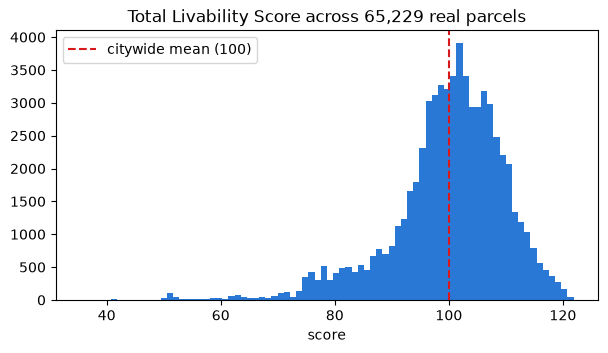

In [15]:
fig, ax = plt.subplots()
ax.hist(total_score, bins=80, color="#2a78d6")
ax.axvline(100, color="#d7191c", linestyle="--", label="citywide mean (100)")
ax.set_title("Total Livability Score across 65,229 real parcels")
ax.set_xlabel("score")
ax.legend()
plt.show()


## Validating against the published quintile breaks

The live map and QGIS styles use quintile (20/40/60/80th percentile) breaks computed directly from this
same scored data. This should exactly reproduce `docs/data/quintile_breaks.json`.


In [16]:
notebook_breaks = [round(float(v), 4) for v in pd.Series(total_score).quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).tolist()]
published_breaks = json.load(open("../docs/data/quintile_breaks.json"))["livability_score"]

print("computed here: ", notebook_breaks)
print("published:     ", published_breaks)
assert notebook_breaks == published_breaks, "quintile breaks do not match the published site"
print("\nMatch confirmed — the live map's color breaks are exactly reproducible from this notebook.")


computed here:  [35.3868, 93.9416, 99.1006, 103.0984, 107.7824, 121.8676]
published:      [35.3868, 93.9416, 99.1006, 103.0984, 107.7824, 121.8676]

Match confirmed — the live map's color breaks are exactly reproducible from this notebook.


## Where this goes next

This scored output feeds:
- The [interactive map](https://crikeli.github.io/tacoma-livability-index/#) (Map tab), rendered as
  vector tiles with a client-side theme toggle across all seven views.
- The [full written report](../report/tacoma_livability_report.html), with neighborhood-level findings
  and stated limitations.
- A downloadable, pre-styled [GeoPackage](https://crikeli.github.io/tacoma-livability-index/) for anyone
  who wants to explore it in their own GIS software.
